In [ ]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# Install if not already available on Kaggle
install.packages(c("dplyr", "readr", "skimr", "lubridate"))

library(dplyr)
library(readr)
library(skimr)
library(lubridate)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘lifecycle’, ‘rlang’, ‘vctrs’, ‘vroom’, ‘timechange’


Warning message in install.packages(c("dplyr", "readr", "skimr", "lubridate")):
“installation of package ‘rlang’ had non-zero exit status”
Warning message in install.packages(c("dplyr", "readr", "skimr", "lubridate")):
“installation of package ‘lifecycle’ had non-zero exit status”
Warning message in install.packages(c("dplyr", "readr", "skimr", "lubridate")):
“installation of package ‘vctrs’ had non-zero exit status”
Warning message in install.packages(c("dplyr", "readr", "skimr", "lubridate")):
“installation of package ‘dplyr’ had non-zero exit status”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked 

In [7]:
list.files("/kaggle/input/datasets/currie32/crimes-in-chicago", 
           recursive = TRUE, 
           full.names = TRUE)

[1] "/kaggle/input/datasets/currie32/crimes-in-chicago/Chicago_Crimes_2001_to_2004.csv"
[2] "/kaggle/input/datasets/currie32/crimes-in-chicago/Chicago_Crimes_2005_to_2007.csv"
[3] "/kaggle/input/datasets/currie32/crimes-in-chicago/Chicago_Crimes_2008_to_2011.csv"
[4] "/kaggle/input/datasets/currie32/crimes-in-chicago/Chicago_Crimes_2012_to_2017.csv"

In [8]:
library(data.table)

path <- "/kaggle/input/datasets/currie32/crimes-in-chicago/"

crime_data <- rbindlist(list(
  fread(paste0(path, "Chicago_Crimes_2001_to_2004.csv")),
  fread(paste0(path, "Chicago_Crimes_2005_to_2007.csv")),
  fread(paste0(path, "Chicago_Crimes_2008_to_2011.csv")),
  fread(paste0(path, "Chicago_Crimes_2012_to_2017.csv"))
), fill = TRUE)

cat("Total Rows   :", nrow(crime_data), "\n")
cat("Total Columns:", ncol(crime_data), "\n")


Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


Warning message in fread(paste0(path, "Chicago_Crimes_2001_to_2004.csv")):
“Stopped early on line 1513591. Expected 23 fields but found 24. Consider fill=TRUE and comment.char=. First discarded non-empty line: <<5118764,,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location>>”
Warning message in fread(paste0(path, "Chicago_Crimes_2005_to_2007.csv")):
“Stopped early on line 533719. Expected 23 fields but found 46. Consider fill=TRUE and comment.char=. First discarded non-empty line: <<537288,5601758,HN409865,06/16/2007 08:15:00 PM,020XX E 94TH ST,1330,CRIMINAL TRESPASS,TO LAND,O

Total Rows   : 4653112 
Total Columns: 23 


In [9]:
# Column names
colnames(crime_data)

# First look
head(crime_data, 5)

# Data types
str(crime_data)

[1] "V1"                   "ID"                   "Case Number"         
 [4] "Date"                 "Block"                "IUCR"                
 [7] "Primary Type"         "Description"          "Location Description"
[10] "Arrest"               "Domestic"             "Beat"                
[13] "District"             "Ward"                 "Community Area"      
[16] "FBI Code"             "X Coordinate"         "Y Coordinate"        
[19] "Year"                 "Updated On"           "Latitude"            
[22] "Longitude"            "Location"

V1,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,⋯,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,⋯,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<chr>
879,4786321,HM399414,01/01/2004 12:01:00 AM,082XX S COLES AVE,0840,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,FALSE,⋯,7,46,06,NA,NA,2004,08/17/2015 03:03:40 PM,NA,NA,
2544,4676906,HM278933,03/01/2003 12:00:00 AM,004XX W 42ND PL,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,FALSE,⋯,11,61,26,1173974,1876757,2003,04/15/2016 08:55:02 AM,41.81723,-87.63733,"(41.817229156, -87.637328162)"
2919,4789749,HM402220,06/20/2004 11:00:00 AM,025XX N KIMBALL AVE,1752,OFFENSE INVOLVING CHILDREN,AGG CRIM SEX ABUSE FAM MEMBER,RESIDENCE,FALSE,⋯,35,22,20,NA,NA,2004,08/17/2015 03:03:40 PM,NA,NA,
2927,4789765,HM402058,12/30/2004 08:00:00 PM,045XX W MONTANA ST,0840,THEFT,FINANCIAL ID THEFT: OVER $300,OTHER,FALSE,⋯,31,20,06,NA,NA,2004,08/17/2015 03:03:40 PM,NA,NA,
3302,4677901,HM275615,05/01/2003 01:00:00 AM,111XX S NORMAL AVE,0841,THEFT,FINANCIAL ID THEFT:$300 &UNDER,RESIDENCE,FALSE,⋯,34,49,06,1174948,1831051,2003,04/15/2016 08:55:02 AM,41.69178,-87.63512,"(41.691784636, -87.635115968)"


Classes ‘data.table’ and 'data.frame':	4653112 obs. of  23 variables:
 $ V1                  : int  879 2544 2919 2927 3302 3633 3756 4502 4564 4904 ...
 $ ID                  : int  4786321 4676906 4789749 4789765 4677901 4838048 4791194 4679521 4792195 4680124 ...
 $ Case Number         : chr  "HM399414" "HM278933" "HM402220" "HM402058" ...
 $ Date                : chr  "01/01/2004 12:01:00 AM" "03/01/2003 12:00:00 AM" "06/20/2004 11:00:00 AM" "12/30/2004 08:00:00 PM" ...
 $ Block               : chr  "082XX S COLES AVE" "004XX W 42ND PL" "025XX N KIMBALL AVE" "045XX W MONTANA ST" ...
 $ IUCR                : chr  "0840" "2825" "1752" "0840" ...
 $ Primary Type        : chr  "THEFT" "OTHER OFFENSE" "OFFENSE INVOLVING CHILDREN" "THEFT" ...
 $ Description         : chr  "FINANCIAL ID THEFT: OVER $300" "HARASSMENT BY TELEPHONE" "AGG CRIM SEX ABUSE FAM MEMBER" "FINANCIAL ID THEFT: OVER $300" ...
 $ Location Description: chr  "RESIDENCE" "RESIDENCE" "RESIDENCE" "OTHER" ...
 $ Arrest      

In [10]:
library(dplyr)
library(lubridate)

# Step 1: Drop useless column
crime_data <- crime_data %>% select(-V1)

# Step 2: Rename columns (remove spaces for easy access)
crime_data <- crime_data %>%
  rename(
    CaseNumber          = `Case Number`,
    PrimaryType         = `Primary Type`,
    LocationDescription = `Location Description`,
    CommunityArea       = `Community Area`,
    FBICode             = `FBI Code`,
    XCoordinate         = `X Coordinate`,
    YCoordinate         = `Y Coordinate`,
    UpdatedOn           = `Updated On`
  )

# Step 3: Parse Date column
crime_data <- crime_data %>%
  mutate(Date = mdy_hms(Date))

# Step 4: Convert types
crime_data <- crime_data %>%
  mutate(
    District      = as.integer(District),
    Ward          = as.integer(Ward),
    CommunityArea = as.integer(CommunityArea)
  )

# Step 5: Remove rows with missing Latitude/Longitude
cat("Rows before removing NA coords:", nrow(crime_data), "\n")
crime_data <- crime_data %>%
  filter(!is.na(Latitude) & !is.na(Longitude))
cat("Rows after removing NA coords :", nrow(crime_data), "\n")

# Step 6: Remove duplicate rows
cat("Rows before dedup:", nrow(crime_data), "\n")
crime_data <- crime_data %>% distinct()
cat("Rows after dedup :", nrow(crime_data), "\n")

# Step 7: Check remaining NAs
colSums(is.na(crime_data))

Rows before removing NA coords: 4653112 
Rows after removing NA coords : 4576548 
Rows before dedup: 4576548 
Rows after dedup : 4576548 


ID          CaseNumber                Date               Block 
                  0                   0                   0                   0 
               IUCR         PrimaryType         Description LocationDescription 
                  0                   0                   0                   0 
             Arrest            Domestic                Beat            District 
                  0                   0                   0                  43 
               Ward       CommunityArea             FBICode         XCoordinate 
             605579              606277                   0                   0 
        YCoordinate                Year           UpdatedOn            Latitude 
                  0                   0                   0                   0 
          Longitude            Location 
                  0                   0

In [11]:
# Fix District NAs (fill with mode)
mode_district <- as.integer(names(sort(table(crime_data$District), decreasing = TRUE)[1]))
crime_data <- crime_data %>%
  mutate(District = ifelse(is.na(District), mode_district, District))

cat("District NAs remaining:", sum(is.na(crime_data$District)), "\n")
cat("Data cleaning complete! Final rows:", nrow(crime_data), "\n")

District NAs remaining: 0 
Data cleaning complete! Final rows: 4576548 


In [13]:
crime_data <- crime_data %>%
  mutate(
    Hour    = hour(Date),
    Day     = day(Date),
    Month   = month(Date),   # numeric 1-12
    Weekday = wday(Date),    # numeric 1-7
    Season  = case_when(
      Month %in% c(12, 1, 2) ~ "Winter",
      Month %in% c(3, 4, 5)  ~ "Spring",
      Month %in% c(6, 7, 8)  ~ "Summer",
      Month %in% c(9, 10, 11)~ "Autumn"
    ),
    TimeOfDay = case_when(
      Hour >= 5  & Hour < 12 ~ "Morning",
      Hour >= 12 & Hour < 17 ~ "Afternoon",
      Hour >= 17 & Hour < 21 ~ "Evening",
      TRUE                   ~ "Night"
    ),
    ArrestNum = as.integer(Arrest)
  )

cat("New columns added successfully!\n")
cat("Total columns now:", ncol(crime_data), "\n")

# Quick check
crime_data %>% 
  count(TimeOfDay) %>% 
  mutate(pct = round(n/sum(n)*100, 1))

New columns added successfully!
Total columns now: 29 


TimeOfDay,n,pct
<chr>,<int>,<dbl>
Afternoon,1178895,25.8
Evening,1014698,22.2
Morning,976460,21.3
Night,1406495,30.7


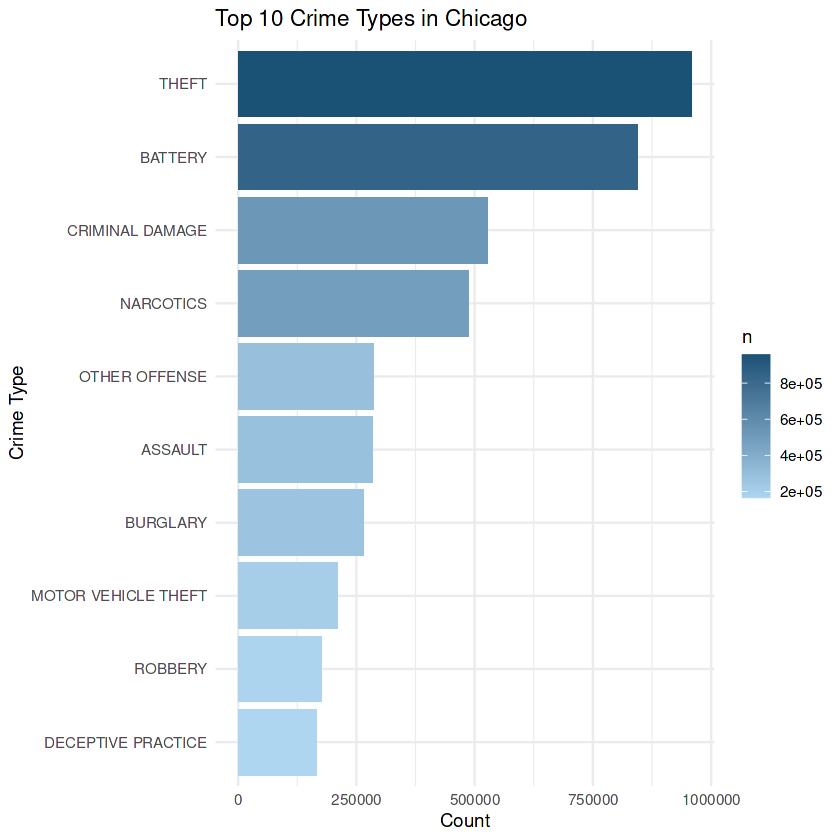

In [14]:
library(ggplot2)

# Plot 1: Top 10 Crime Types
top10 <- crime_data %>%
  count(PrimaryType, sort = TRUE) %>%
  head(10)

ggplot(top10, aes(x = reorder(PrimaryType, n), y = n, fill = n)) +
  geom_col() +
  coord_flip() +
  scale_fill_gradient(low = "#AED6F1", high = "#1A5276") +
  labs(title = "Top 10 Crime Types in Chicago",
       x = "Crime Type", y = "Count") +
  theme_minimal()

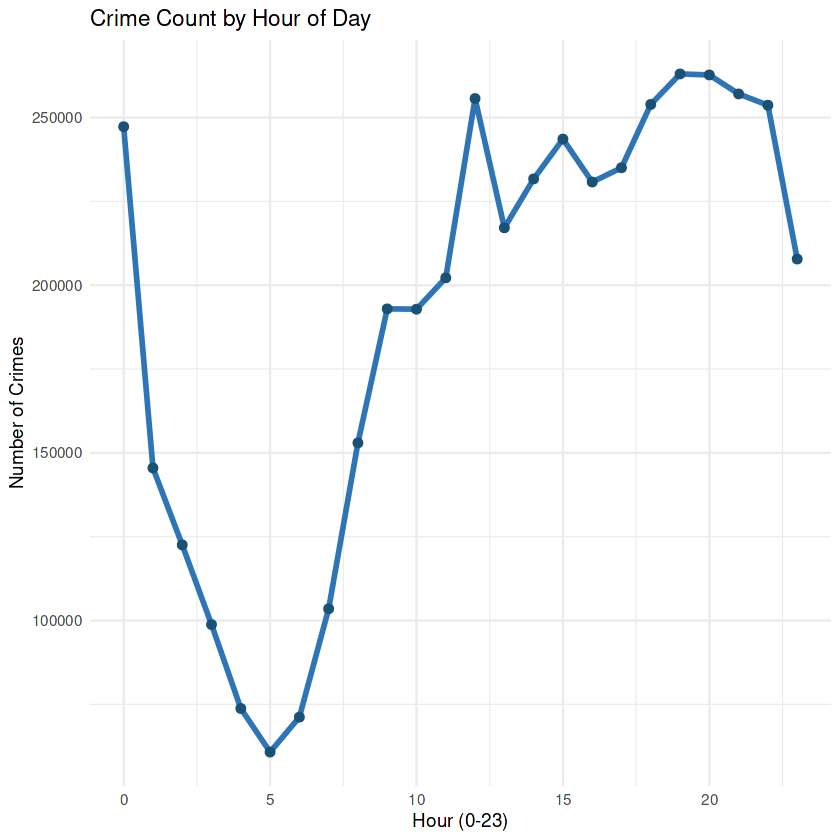

In [15]:
# Plot 2: Crimes by Hour of Day
crime_data %>%
  count(Hour) %>%
  ggplot(aes(x = Hour, y = n)) +
  geom_line(color = "#2E75B6", linewidth = 1.2) +
  geom_point(color = "#1A5276", size = 2) +
  labs(title = "Crime Count by Hour of Day",
       x = "Hour (0-23)", y = "Number of Crimes") +
  theme_minimal()

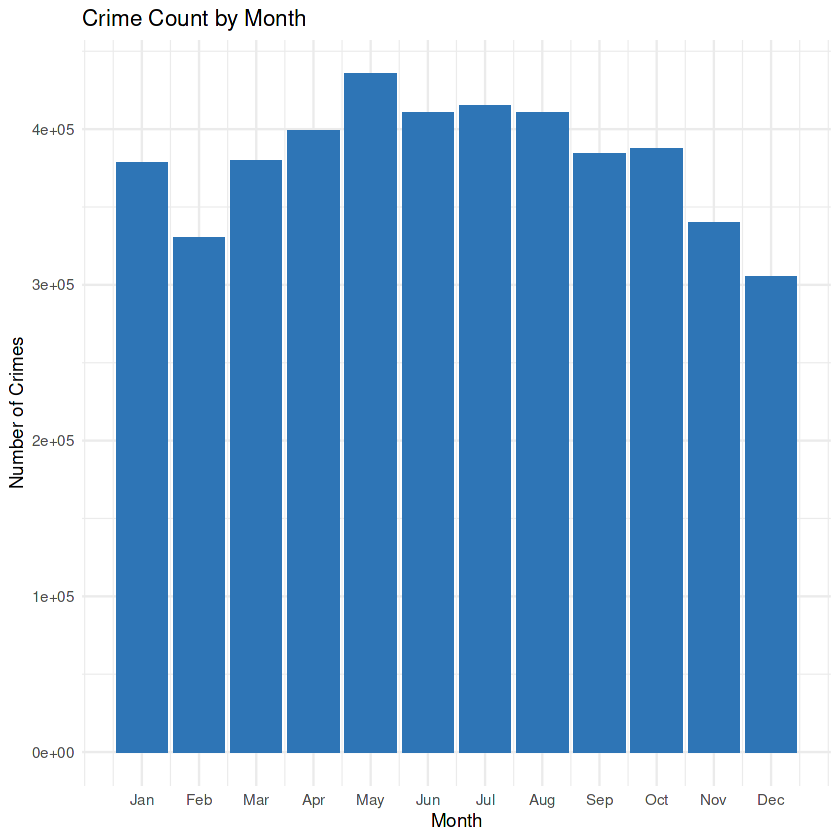

In [16]:
# Plot 3: Crimes by Month
crime_data %>%
  count(Month) %>%
  ggplot(aes(x = Month, y = n)) +
  geom_col(fill = "#2E75B6") +
  scale_x_continuous(breaks = 1:12,
    labels = c("Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec")) +
  labs(title = "Crime Count by Month",
       x = "Month", y = "Number of Crimes") +
  theme_minimal()

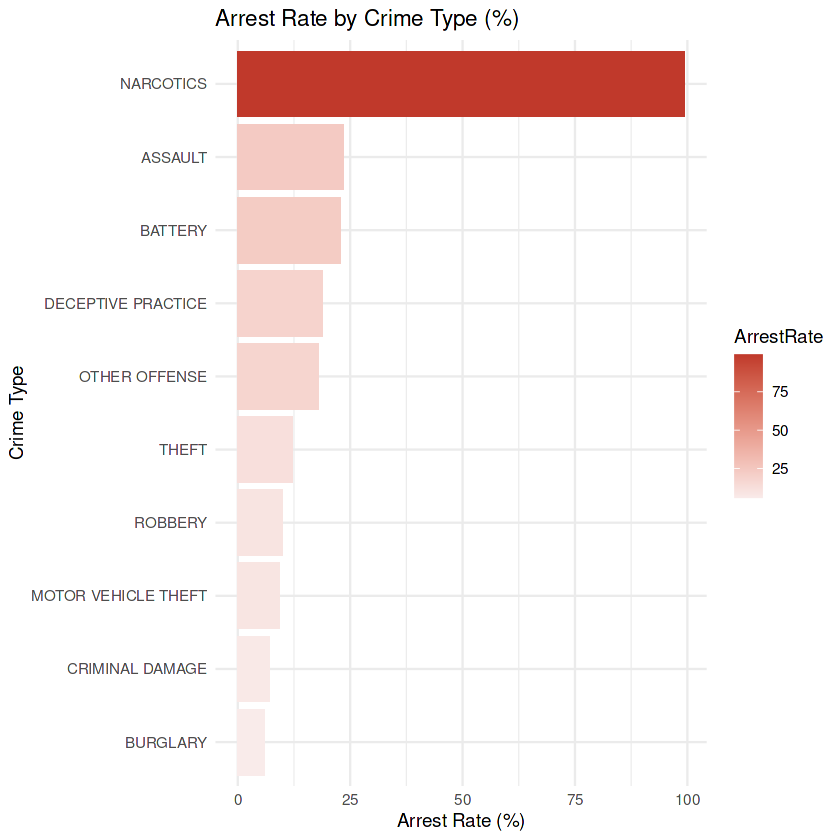

In [17]:
# Plot 4: Arrest Rate by Crime Type (Top 10)
crime_data %>%
  filter(PrimaryType %in% top10$PrimaryType) %>%
  group_by(PrimaryType) %>%
  summarise(ArrestRate = mean(ArrestNum) * 100) %>%
  ggplot(aes(x = reorder(PrimaryType, ArrestRate), 
             y = ArrestRate, fill = ArrestRate)) +
  geom_col() +
  coord_flip() +
  scale_fill_gradient(low = "#F9EBEA", high = "#C0392B") +
  labs(title = "Arrest Rate by Crime Type (%)",
       x = "Crime Type", y = "Arrest Rate (%)") +
  theme_minimal()

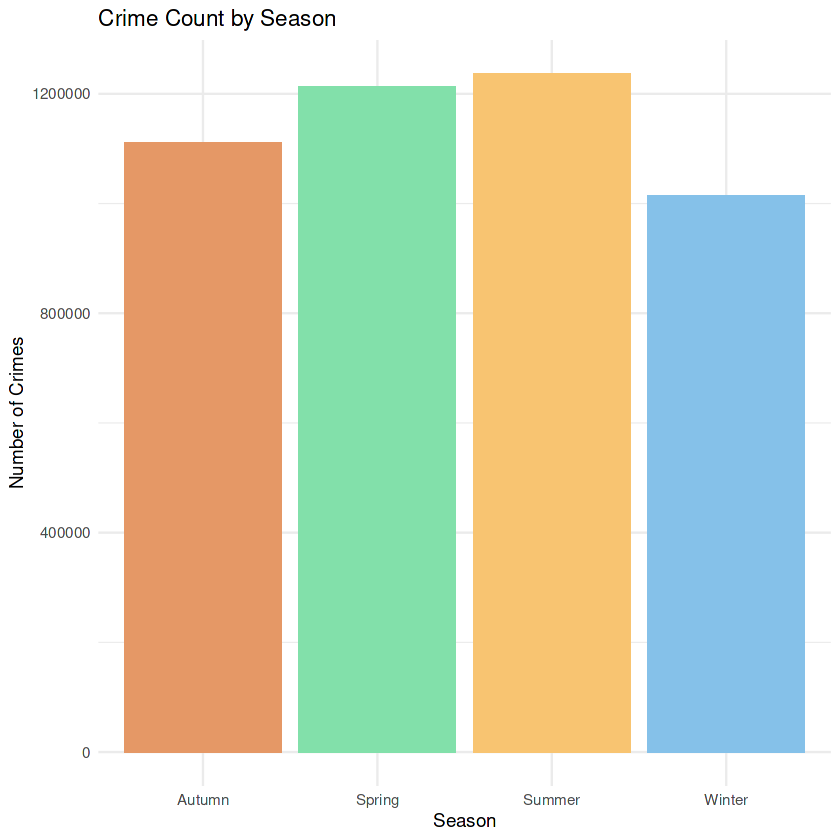

In [18]:
# Plot 5: Crimes by Season
crime_data %>%
  count(Season) %>%
  ggplot(aes(x = Season, y = n, fill = Season)) +
  geom_col(show.legend = FALSE) +
  scale_fill_manual(values = c(
    "Winter" = "#85C1E9",
    "Spring" = "#82E0AA",
    "Summer" = "#F8C471",
    "Autumn" = "#E59866"
  )) +
  labs(title = "Crime Count by Season",
       x = "Season", y = "Number of Crimes") +
  theme_minimal()

In [19]:
library(randomForest)

# Sample 50k rows (full 4.5M will crash Kaggle RAM)
set.seed(42)
sample_data <- crime_data %>%
  select(Arrest, PrimaryType, District, Hour, Month, 
         Weekday, Season, TimeOfDay, Domestic) %>%
  mutate(
    PrimaryType = as.factor(PrimaryType),
    Season      = as.factor(Season),
    TimeOfDay   = as.factor(TimeOfDay),
    Arrest      = as.factor(Arrest)
  ) %>%
  sample_n(50000)

# Train/Test Split (80/20)
set.seed(42)
train_idx  <- sample(1:nrow(sample_data), 0.8 * nrow(sample_data))
train_data <- sample_data[train_idx, ]
test_data  <- sample_data[-train_idx, ]

cat("Train size:", nrow(train_data), "\n")
cat("Test size :", nrow(test_data), "\n")

# Train Random Forest
rf_model <- randomForest(
  Arrest ~ .,
  data       = train_data,
  ntree      = 100,
  importance = TRUE
)

print(rf_model)

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


The following object is masked from ‘package:dplyr’:

    combine




Train size: 40000 
Test size : 10000 

Call:
 randomForest(formula = Arrest ~ ., data = train_data, ntree = 100,      importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 100
No. of variables tried at each split: 2

        OOB estimate of  error rate: 13.76%
Confusion matrix:
      FALSE TRUE class.error
FALSE 28261  540  0.01874935
TRUE   4966 6233  0.44343245


In [20]:
library(caret)

# Predictions
rf_pred <- predict(rf_model, test_data)

# Confusion Matrix
conf_matrix <- confusionMatrix(rf_pred, test_data$Arrest)
print(conf_matrix)

# Accuracy
cat("\nAccuracy:", round(conf_matrix$overall["Accuracy"] * 100, 2), "%\n")

Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:httr’:

    progress




Confusion Matrix and Statistics

          Reference
Prediction FALSE TRUE
     FALSE  7104 1232
     TRUE    147 1517
                                          
               Accuracy : 0.8621          
                 95% CI : (0.8552, 0.8688)
    No Information Rate : 0.7251          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.6058          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.9797          
            Specificity : 0.5518          
         Pos Pred Value : 0.8522          
         Neg Pred Value : 0.9117          
             Prevalence : 0.7251          
         Detection Rate : 0.7104          
   Detection Prevalence : 0.8336          
      Balanced Accuracy : 0.7658          
                                          
       'Positive' Class : FALSE           
                     

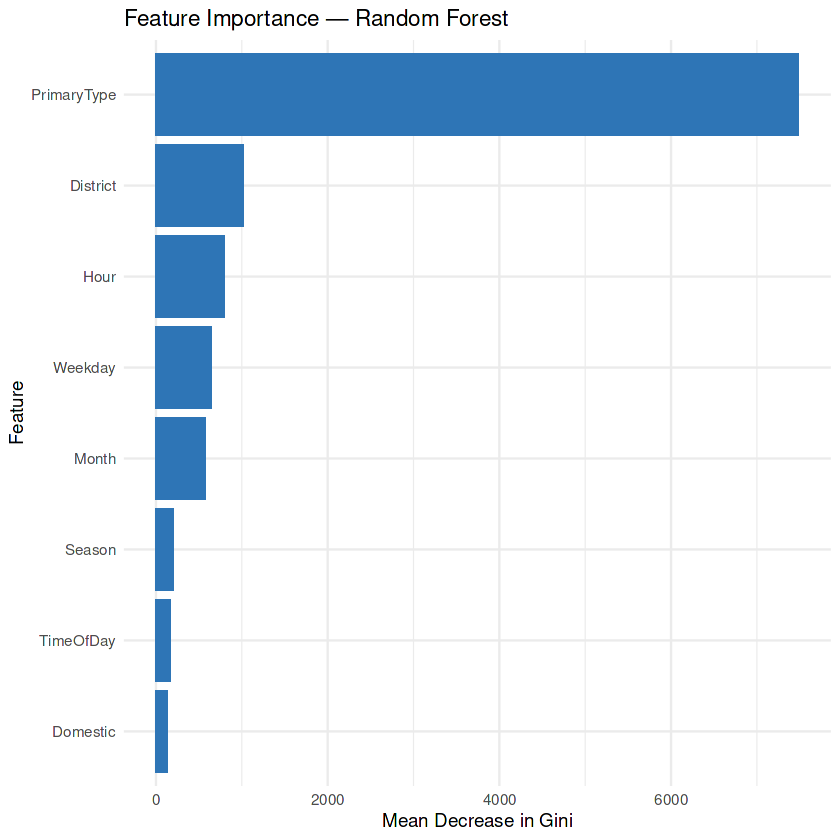

In [21]:
# Feature Importance Plot
importance_df <- as.data.frame(importance(rf_model))
importance_df$Feature <- rownames(importance_df)

ggplot(importance_df, aes(x = reorder(Feature, MeanDecreaseGini), 
                           y = MeanDecreaseGini)) +
  geom_col(fill = "#2E75B6") +
  coord_flip() +
  labs(title = "Feature Importance — Random Forest",
       x = "Feature", y = "Mean Decrease in Gini") +
  theme_minimal()

In [22]:
# Aggregate: crimes per month per district
monthly_crime <- crime_data %>%
  group_by(Year, Month, District) %>%
  summarise(CrimeCount = n(), .groups = "drop")

cat("Rows:", nrow(monthly_crime), "\n")
head(monthly_crime, 5)

Rows: 3900 


Year,Month,District,CrimeCount
<int>,<int>,<int>,<int>
2001,1,1,1280
2001,1,2,3071
2001,1,3,1815
2001,1,4,1918
2001,1,5,1411


In [23]:
# Train/Test Split
set.seed(42)
train_idx2  <- sample(1:nrow(monthly_crime), 0.8 * nrow(monthly_crime))
train_lm    <- monthly_crime[train_idx2, ]
test_lm     <- monthly_crime[-train_idx2, ]

# Train Linear Regression
lm_model <- lm(CrimeCount ~ Year + Month + District, data = train_lm)
summary(lm_model)


Call:
lm(formula = CrimeCount ~ Year + Month + District, data = train_lm)

Residuals:
     Min       1Q   Median       3Q      Max 
-1611.69  -255.12    86.13   424.08  1643.24 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 74528.715   5003.813  14.894   <2e-16 ***
Year          -36.400      2.491 -14.610   <2e-16 ***
Month           4.331      3.458   1.253     0.21    
District      -21.734      1.609 -13.510   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 663.1 on 3116 degrees of freedom
Multiple R-squared:  0.1143,	Adjusted R-squared:  0.1134 
F-statistic:   134 on 3 and 3116 DF,  p-value: < 2.2e-16


In [24]:
# Evaluate
lm_pred <- predict(lm_model, test_lm)

# RMSE and R-squared
rmse <- sqrt(mean((test_lm$CrimeCount - lm_pred)^2))
ss_res <- sum((test_lm$CrimeCount - lm_pred)^2)
ss_tot <- sum((test_lm$CrimeCount - mean(test_lm$CrimeCount))^2)
r2 <- 1 - (ss_res / ss_tot)

cat("RMSE      :", round(rmse, 2), "\n")
cat("R-Squared :", round(r2, 4), "\n")

RMSE      : 675.13 
R-Squared : 0.083 


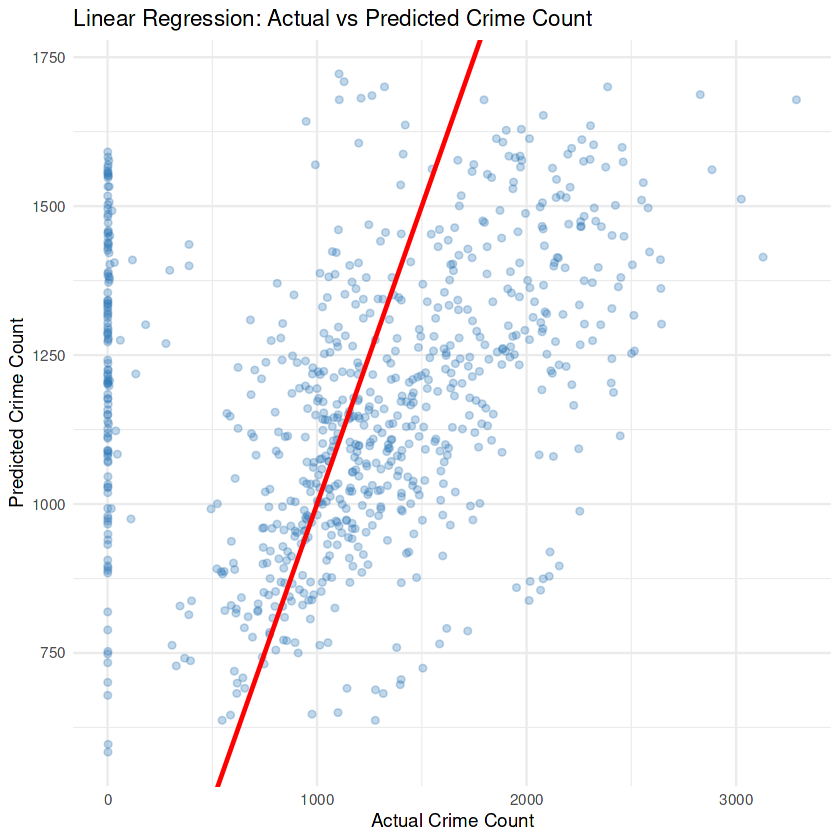

In [25]:
# Actual vs Predicted Plot
test_lm$Predicted <- lm_pred

ggplot(test_lm, aes(x = CrimeCount, y = Predicted)) +
  geom_point(alpha = 0.3, color = "#2E75B6") +
  geom_abline(slope = 1, intercept = 0, color = "red", linewidth = 1) +
  labs(title = "Linear Regression: Actual vs Predicted Crime Count",
       x = "Actual Crime Count", y = "Predicted Crime Count") +
  theme_minimal()

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5000000)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5000000)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5000000)”


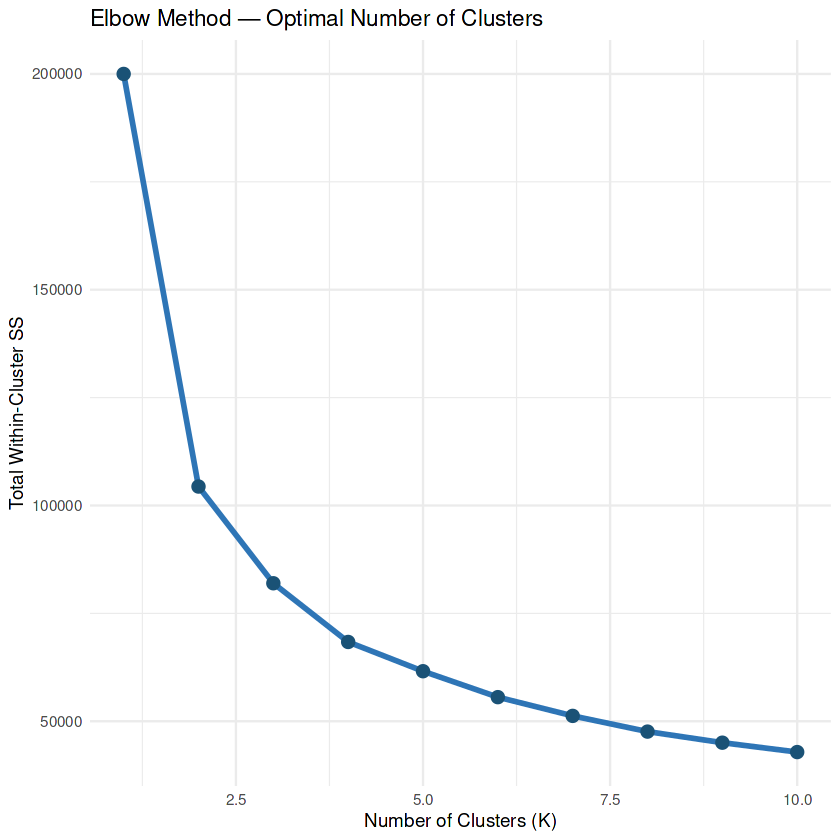

In [26]:
# Sample 100k points for clustering (lat/long only)
set.seed(42)
coords <- crime_data %>%
  select(Latitude, Longitude, PrimaryType) %>%
  sample_n(100000)

# Scale coordinates
coords_scaled <- scale(coords[, c("Latitude", "Longitude")])

# Find optimal K using Elbow Method
wss <- sapply(1:10, function(k) {
  kmeans(coords_scaled, centers = k, nstart = 10)$tot.withinss
})

# Elbow Plot
elbow_df <- data.frame(K = 1:10, WSS = wss)
ggplot(elbow_df, aes(x = K, y = WSS)) +
  geom_line(color = "#2E75B6", linewidth = 1.2) +
  geom_point(color = "#1A5276", size = 3) +
  labs(title = "Elbow Method — Optimal Number of Clusters",
       x = "Number of Clusters (K)", y = "Total Within-Cluster SS") +
  theme_minimal()

Cluster sizes:

    1     2     3     4     5 
22894 26024 14558 19497 17027 


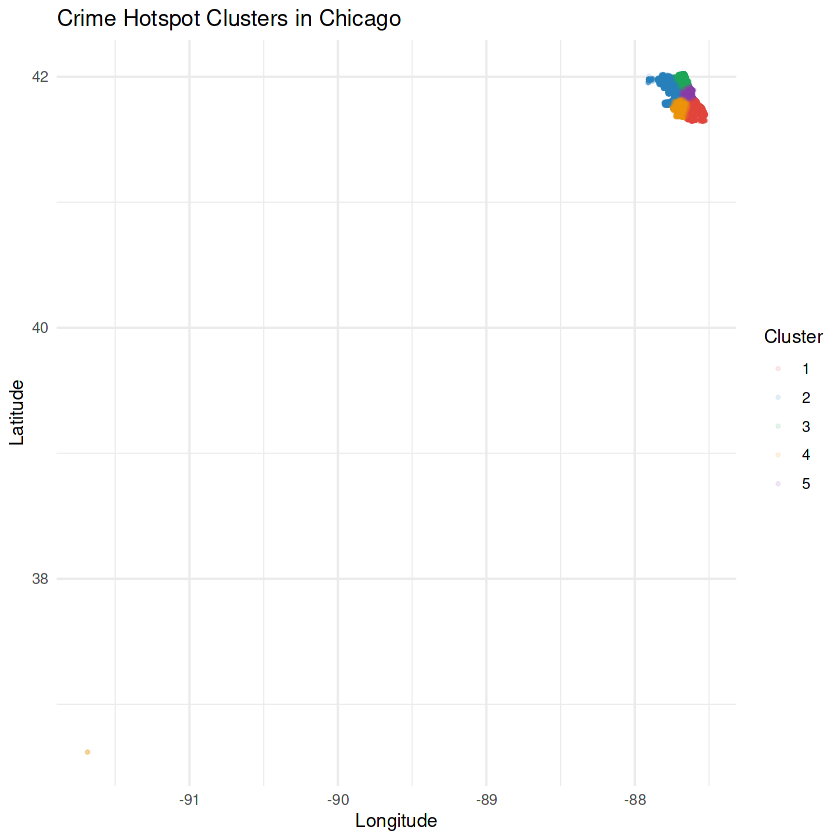

In [27]:
# Run K-Means with K=5 (Chicago has ~5 major crime zones)
set.seed(42)
km_model <- kmeans(coords_scaled, centers = 5, nstart = 25)

# Add cluster labels back
coords$Cluster <- as.factor(km_model$cluster)

cat("Cluster sizes:\n")
print(table(coords$Cluster))

# Plot clusters
ggplot(coords, aes(x = Longitude, y = Latitude, color = Cluster)) +
  geom_point(alpha = 0.1, size = 0.5) +
  scale_color_manual(values = c("#E74C3C","#2E86C1","#27AE60","#F39C12","#8E44AD")) +
  labs(title = "Crime Hotspot Clusters in Chicago",
       x = "Longitude", y = "Latitude") +
  theme_minimal()

Cluster sizes:

    1     2     3     4     5 
19684 26618 16737 14620 22341 


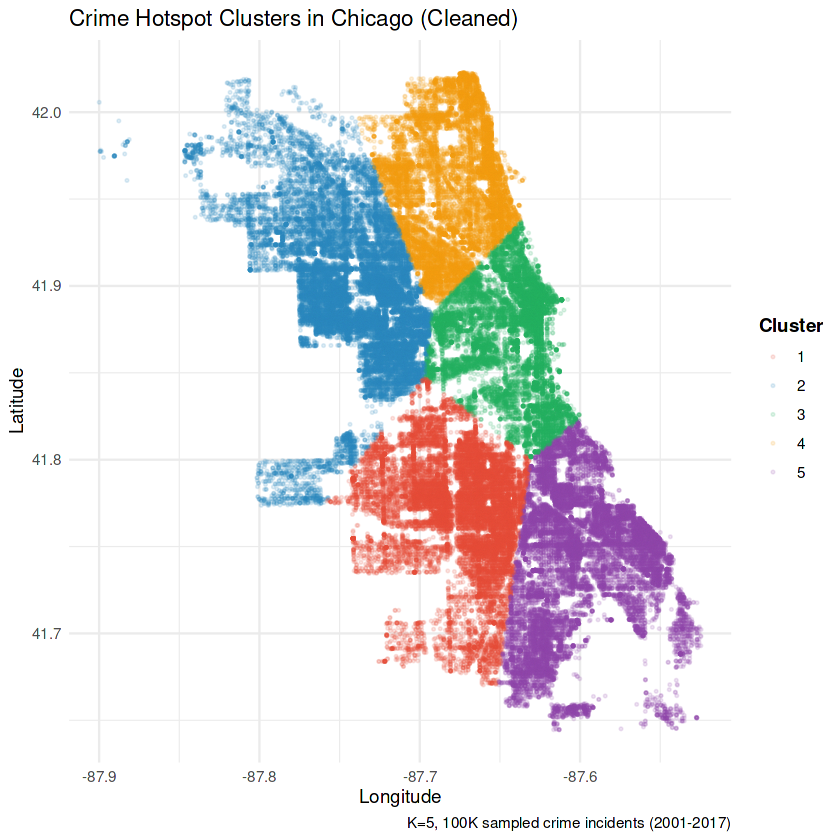

In [28]:
# Chicago bounding box: Lat 41.6-42.05, Long -87.9 to -87.5
coords_clean <- crime_data %>%
  filter(Latitude  >= 41.6 & Latitude  <= 42.05,
         Longitude >= -87.9 & Longitude <= -87.5) %>%
  select(Latitude, Longitude, PrimaryType) %>%
  sample_n(100000)

# Re-run K-Means
set.seed(42)
coords_scaled2 <- scale(coords_clean[, c("Latitude", "Longitude")])
km_model2 <- kmeans(coords_scaled2, centers = 5, nstart = 25)
coords_clean$Cluster <- as.factor(km_model2$cluster)

cat("Cluster sizes:\n")
print(table(coords_clean$Cluster))

# Clean Hotspot Plot
ggplot(coords_clean, aes(x = Longitude, y = Latitude, color = Cluster)) +
  geom_point(alpha = 0.15, size = 0.4) +
  scale_color_manual(values = c("#E74C3C","#2E86C1","#27AE60","#F39C12","#8E44AD")) +
  labs(title = "Crime Hotspot Clusters in Chicago (Cleaned)",
       x = "Longitude", y = "Latitude",
       caption = "K=5, 100K sampled crime incidents (2001-2017)") +
  theme_minimal() +
  theme(legend.title = element_text(face = "bold"))

In [29]:
# Save everything we need for dashboard
saveRDS(crime_data, "/kaggle/working/crime_data_clean.rds")
saveRDS(coords_clean, "/kaggle/working/coords_clusters.rds")
saveRDS(km_model2, "/kaggle/working/kmeans_model.rds")
saveRDS(rf_model, "/kaggle/working/rf_model.rds")

cat("All files saved!\n")
list.files("/kaggle/working/")

All files saved!


[1] "coords_clusters.rds"  "crime_data_clean.rds" "kmeans_model.rds"    
[4] "rf_model.rds"